# sPHENIX TPC: fields from stored Green kernels and interpolation studies

## Purpose

This notebook reads the Green-function kernels generated by the direct Green-function notebook and uses them to calculate new electric fields for a configurable charge distribution.

The workflow is

$$
\text{stored kernels}
\longrightarrow
\text{kernel QA}
\longrightarrow
\rho(r',\phi',z')
\longrightarrow
\Phi,\ E_r,\ E_\phi,\ E_z.
$$

It also tests whether a smaller stored kernel representation can reproduce the full result.

The notebook compares:

1. the full six-dimensional stored kernels;
2. an axisymmetric four-dimensional reduction,
   $$
   K(r,z;r',z');
   $$
3. a coarsened four-dimensional kernel that is interpolated back to the original grid;
4. interpolation of the final field maps themselves.

This is intended as a prototype for future run-by-run operation. The detector-geometry kernels can be generated once, while the source density can change for each run according to data.

## 1. Meaning of the kernel indices

The stored Green function is

$$
G(r,\phi,z;r',\phi',z').
$$

The first three coordinates belong to the observation point,

$$
x=(r,\phi,z),
$$

and the last three belong to the source point,

$$
x'=(r',\phi',z').
$$

After flattening the grids, the kernel becomes a matrix,

$$
G_{ij},
$$

where

$$
i\longleftrightarrow(r_i,\phi_i,z_i)
$$

labels one observation bin and

$$
j\longleftrightarrow(r'_j,\phi'_j,z'_j)
$$

labels one source voxel.

For source charge

$$
\Delta Q_j=\rho_j\Delta V_j,
$$

the potential is

$$
\Phi_i=\frac{1}{\epsilon_0}\sum_j G_{ij}\Delta Q_j,
$$

and the field components follow from the stored differentiated kernels.

In [1]:
import json
import time
from pathlib import Path

import numpy as np
import ROOT as root
from scipy.interpolate import RegularGridInterpolator
from IPython.display import display, Image

root.gROOT.SetBatch(True)
root.gStyle.SetOptStat(0)
root.gStyle.SetNumberContours(80)

EPSILON_0 = 8.8541878128e-12
M_TO_CM = 100.0

Welcome to JupyROOT 6.30/06


In [2]:
# ============================================================
# User configuration
# ============================================================

GREEN_KERNEL_FILE = "sphenix_direct_green_kernels.root"
GREEN_TREE_NAME = "GreenKernels"

# Run-dependent source model
RHO_REFERENCE_NC_PER_M3 = 20.0
K_EFF = 1.0
RADIAL_POWER_ALPHA = 1.0
M1_AMPLITUDE, M1_PHASE = 0.0, 0.0
M12_AMPLITUDE, M12_PHASE = 0.0, 0.0

# Tests
DO_KERNEL_HOLDOUT_TEST = True
DO_AXISYMMETRIC_REDUCTION_TEST = True
DO_COARSE_KERNEL_TEST = True
DO_FIELD_INTERPOLATION_TEST = True

# Refinement study: interpolate stored 4D kernels to finer grids.
# A factor of 2 inserts one new point between each pair of original points.
# A factor of 4 inserts three new points. Original endpoints and nodes remain.
DO_REFINED_KERNEL_TEST = True
KERNEL_REFINEMENT_FACTORS = (2, 4)


# Coarsening factors
COARSE_STRIDE_OBS_R = 2
COARSE_STRIDE_OBS_Z = 2
COARSE_STRIDE_SRC_R = 2
COARSE_STRIDE_SRC_Z = 2
FIELD_STRIDE_R = 2
FIELD_STRIDE_Z = 2

QA_DIR = Path("kernel_interpolation_qa")
QA_DIR.mkdir(exist_ok=True)

OUTPUT_FIELD_FILE = "sphenix_fields_from_stored_kernels.root"
OUTPUT_GARFIELD_FILE = "sphenix_garfield_fields_from_stored_kernels.root"

## 2. Read the Green-kernel ROOT file

The input tree contains one row for each source-observation pair.

The integer branches

```text
iro, ipo, izo, irs, ips, izs
```

store the six grid indices. The floating-point branches

```text
ro, po, zo, rs, ps, zs
```

store the physical coordinates. The kernel branches are

```text
G, Kr, Kp, Kz
```

with

$$
K_r=-\frac{\partial G}{\partial r},\qquad
K_\phi=-\frac{1}{r}\frac{\partial G}{\partial\phi},\qquad
K_z=-\frac{\partial G}{\partial z}.
$$

The tree is reconstructed into dense arrays with axis order

$$
(r,\phi,z,r',\phi',z').
$$

In [3]:
input_path = Path(GREEN_KERNEL_FILE)
if not input_path.exists():
    raise FileNotFoundError(
        f"Cannot find {GREEN_KERNEL_FILE}. Run the kernel-generation notebook first."
    )

branches = [
    "iro","ipo","izo","irs","ips","izs",
    "ro","po","zo","rs","ps","zs",
    "G","Kr","Kp","Kz"
]

data = root.RDataFrame(GREEN_TREE_NAME, str(input_path)).AsNumpy(branches)

idx_arrays = {name: np.asarray(data[name], dtype=np.int64)
              for name in ["iro","ipo","izo","irs","ips","izs"]}

iro,ipo,izo = idx_arrays["iro"],idx_arrays["ipo"],idx_arrays["izo"]
irs,ips,izs = idx_arrays["irs"],idx_arrays["ips"],idx_arrays["izs"]

NR_OBS,NPHI_OBS,NZ_OBS = int(iro.max())+1,int(ipo.max())+1,int(izo.max())+1
NR_SRC,NPHI_SRC,NZ_SRC = int(irs.max())+1,int(ips.max())+1,int(izs.max())+1
shape=(NR_OBS,NPHI_OBS,NZ_OBS,NR_SRC,NPHI_SRC,NZ_SRC)

G=np.empty(shape); Kr=np.empty(shape); Kp=np.empty(shape); Kz=np.empty(shape)
index=(iro,ipo,izo,irs,ips,izs)
G[index]=np.asarray(data["G"]); Kr[index]=np.asarray(data["Kr"])
Kp[index]=np.asarray(data["Kp"]); Kz[index]=np.asarray(data["Kz"])

def axis_from_tree(values, indices, n):
    out=np.empty(n)
    values=np.asarray(values)
    for i in range(n):
        selected=values[indices==i]
        if selected.size==0:
            raise RuntimeError(f"Missing grid index {i}")
        out[i]=selected[0]
    return out

r_obs=axis_from_tree(data["ro"],iro,NR_OBS)
phi_obs=axis_from_tree(data["po"],ipo,NPHI_OBS)
z_obs=axis_from_tree(data["zo"],izo,NZ_OBS)
r_src=axis_from_tree(data["rs"],irs,NR_SRC)
phi_src=axis_from_tree(data["ps"],ips,NPHI_SRC)
z_src=axis_from_tree(data["zs"],izs,NZ_SRC)

NOBS=NR_OBS*NPHI_OBS*NZ_OBS
NSRC=NR_SRC*NPHI_SRC*NZ_SRC
print("Kernel shape:",shape)
print("Observation points:",NOBS)
print("Source points:",NSRC)
print("Kernel memory [MiB]",(G.nbytes+Kr.nbytes+Kp.nbytes+Kz.nbytes)/1024**2)

Kernel shape: (40, 2, 40, 40, 2, 40)
Observation points: 3200
Source points: 3200
Kernel memory [MiB] 312.5


## 3. Reconstruct bin edges and source-voxel volumes

The tree stores grid centers. Bin edges are reconstructed by placing interior boundaries halfway between neighboring centers.

For a cylindrical source voxel,

$$
\Delta V
=
\frac12\left(r_{\rm high}^2-r_{\rm low}^2\right)
\Delta\phi\,\Delta z.
$$

These volumes are needed to convert the density into charge per source voxel.

In [4]:
def centers_to_edges(x):
    x=np.asarray(x)
    if x.size<2: raise ValueError("At least two centers are required")
    e=np.empty(x.size+1)
    e[1:-1]=0.5*(x[:-1]+x[1:])
    e[0]=x[0]-0.5*(x[1]-x[0])
    e[-1]=x[-1]+0.5*(x[-1]-x[-2])
    return e

r_obs_edges=centers_to_edges(r_obs); phi_obs_edges=centers_to_edges(phi_obs); z_obs_edges=centers_to_edges(z_obs)
r_src_edges=centers_to_edges(r_src); phi_src_edges=centers_to_edges(phi_src); z_src_edges=centers_to_edges(z_src)

dV=(
    0.5*(r_src_edges[1:]**2-r_src_edges[:-1]**2)[:,None,None]
    *np.diff(phi_src_edges)[None,:,None]
    *np.diff(z_src_edges)[None,None,:]
)
print("Total source volume [m^3]:",np.sum(dV))

Total source volume [m^3]: 1.7237127764452245


## 4. Kernel integrity checks

Before using the kernels, the notebook verifies that all arrays are finite and that all coordinate axes are strictly increasing.

For an axisymmetric kernel, the azimuthal kernel should be negligible:

$$
K_\phi\approx0.
$$

In [5]:
for name,arr in [("G",G),("Kr",Kr),("Kp",Kp),("Kz",Kz)]:
    if not np.all(np.isfinite(arr)):
        raise RuntimeError(f"{name} contains non-finite values")
for name,axis in [("r_obs",r_obs),("phi_obs",phi_obs),("z_obs",z_obs),
                  ("r_src",r_src),("phi_src",phi_src),("z_src",z_src)]:
    if not np.all(np.diff(axis)>0):
        raise RuntimeError(f"{name} is not strictly increasing")
scale=max(np.max(abs(Kr)),np.max(abs(Kz)),1e-30)
print("max |Kp| / max(|Kr|,|Kz|) =",np.max(abs(Kp))/scale)

max |Kp| / max(|Kr|,|Kz|) = 0.0


## 5. Build a run-dependent charge distribution

The kernel file is source independent. A new density can be supplied for every run.

The default source is

$$
\rho(r',\phi',z')\propto
\frac{1}{r'^\alpha}
\left[1+A_1\cos(\phi'-\phi_1)+A_{12}\cos12(\phi'-\phi_{12})\right].
$$

The volume-weighted mean is normalized to

$$
K_{\rm eff}\times20\ \mathrm{nC/m^3}.
$$

In [15]:
r_min = r_src_edges[0]
r_max = r_src_edges[-1]
print(f"Source radial range: {r_min:.3f} m to {r_max:.3f} m")

Source radial range: 0.200 m to 0.759 m


In [6]:
R3=r_src[:,None,None]
P3=phi_src[None,:,None]
raw=(r_src[0]/R3)**RADIAL_POWER_ALPHA*(
    1+M1_AMPLITUDE*np.cos(P3-M1_PHASE)
    +M12_AMPLITUDE*np.cos(12*(P3-M12_PHASE))
)*np.ones((1,1,NZ_SRC))
if np.min(raw)<0: raise ValueError("The selected source becomes negative")
target=K_EFF*RHO_REFERENCE_NC_PER_M3*1e-9
rho=target*raw/(np.sum(raw*dV)/np.sum(dV))
charge=rho*dV
qvec=charge.reshape(NSRC)
print("Mean rho [C/m^3]:",np.sum(rho*dV)/np.sum(dV))
print("Total charge [C]:",np.sum(charge))

Mean rho [C/m^3]: 2e-08
Total charge [C]: 3.447425552890449e-08


## 6. Reference fields from the full stored kernels

The full six-dimensional arrays are reshaped into matrices of size

$$
N_{\rm obs}\times N_{\rm src}.
$$

Each row corresponds to one observation bin and each column to one source voxel.

The full-kernel result is the reference for all later comparisons.

In [7]:
t0=time.time()
Phi_full=(G.reshape(NOBS,NSRC)@qvec/EPSILON_0).reshape(NR_OBS,NPHI_OBS,NZ_OBS)
Er_full=(Kr.reshape(NOBS,NSRC)@qvec/EPSILON_0).reshape(NR_OBS,NPHI_OBS,NZ_OBS)
Ephi_full=(Kp.reshape(NOBS,NSRC)@qvec/EPSILON_0).reshape(NR_OBS,NPHI_OBS,NZ_OBS)
Ez_full=(Kz.reshape(NOBS,NSRC)@qvec/EPSILON_0).reshape(NR_OBS,NPHI_OBS,NZ_OBS)
print("Convolution time [s]:",time.time()-t0)
print("max |Phi|",np.max(abs(Phi_full)))
print("max |Er|",np.max(abs(Er_full)))
print("max |Ephi|",np.max(abs(Ephi_full)))
print("max |Ez|",np.max(abs(Ez_full)))

Convolution time [s]: 0.0069162845611572266
max |Phi| 86.81162541582171
max |Er| 1018.3146084438007
max |Ephi| 0.0
max |Ez| 505.3708259672665


## 7. Omitted-point interpolation test for the kernels

Including a target point in the interpolation grid would reproduce it trivially. Instead, this notebook performs a systematic holdout test:

1. retain only a coarser subset of grid points;
2. construct a multilinear interpolator from the retained points;
3. evaluate it at omitted locations where the exact stored kernel is known;
4. compare interpolated and exact values.

This is the practical regular-grid version of predicting known points from surrounding points.

The test is performed on the axisymmetric four-dimensional kernels

$$
K(r,z;r',z').
$$

In [20]:
def retained_indices(n, stride):
    """
    Keep every `stride`-th node, but always keep the first and last nodes.
    """
    idx = list(range(0, n, stride))
    if idx[0] != 0:
        idx.insert(0, 0)
    if idx[-1] != n - 1:
        idx.append(n - 1)
    return np.asarray(sorted(set(idx)), dtype=int)


def refine_axis_keep_nodes(axis, factor):
    """
    Subdivide every interval into `factor` equal intervals while preserving
    all original nodes and both endpoints exactly.
    """
    axis = np.asarray(axis, dtype=np.float64)
    if factor < 1 or int(factor) != factor:
        raise ValueError("factor must be a positive integer")
    factor = int(factor)
    if factor == 1:
        return axis.copy()

    refined = []
    for i in range(axis.size - 1):
        segment = np.linspace(axis[i], axis[i + 1], factor + 1)
        refined.extend(segment[:-1])
    refined.append(axis[-1])
    return np.asarray(refined, dtype=np.float64)


def centers_to_edges_with_fixed_bounds(centers, lower, upper):
    """
    Construct integration-cell edges while keeping the original physical
    lower and upper boundaries exactly fixed.
    """
    centers = np.asarray(centers, dtype=np.float64)
    if centers.size < 2:
        raise ValueError("At least two centers are required.")

    edges = np.empty(centers.size + 1, dtype=np.float64)
    edges[1:-1] = 0.5 * (centers[:-1] + centers[1:])
    edges[0] = lower
    edges[-1] = upper

    if not np.all(np.diff(edges) > 0):
        raise ValueError("Constructed edges are not strictly increasing.")
    return edges


def metrics(ref, test):
    ref = np.asarray(ref)
    test = np.asarray(test)
    peak = max(np.max(np.abs(ref)), 1e-30)
    return {
        "rms_abs": float(np.sqrt(np.mean((test - ref)**2))),
        "max_abs": float(np.max(np.abs(test - ref))),
        "global_rms_fraction": float(
            np.sqrt(np.mean((test - ref)**2)) / peak
        ),
        "global_max_fraction": float(
            np.max(np.abs(test - ref)) / peak
        ),
    }


holdout_results = {}

G4 = np.mean(G, axis=(1, 4))
Kr4 = np.mean(Kr, axis=(1, 4))
Kz4 = np.mean(Kz, axis=(1, 4))

if DO_KERNEL_HOLDOUT_TEST:
    io = retained_indices(NR_OBS, COARSE_STRIDE_OBS_R)
    jo = retained_indices(NZ_OBS, COARSE_STRIDE_OBS_Z)
    isrc = retained_indices(NR_SRC, COARSE_STRIDE_SRC_R)
    jsrc = retained_indices(NZ_SRC, COARSE_STRIDE_SRC_Z)

    print("Retained observation-r endpoints:",
          io[0], io[-1], "of", NR_OBS - 1)
    print("Retained observation-z endpoints:",
          jo[0], jo[-1], "of", NZ_OBS - 1)
    print("Retained source-r endpoints:",
          isrc[0], isrc[-1], "of", NR_SRC - 1)
    print("Retained source-z endpoints:",
          jsrc[0], jsrc[-1], "of", NZ_SRC - 1)

    axes = (
        r_obs[io],
        z_obs[jo],
        r_src[isrc],
        z_src[jsrc],
    )

    mesh = np.meshgrid(
        r_obs,
        z_obs,
        r_src,
        z_src,
        indexing="ij",
    )
    points = np.column_stack([x.ravel() for x in mesh])

    retained = np.zeros(G4.shape, dtype=bool)
    retained[np.ix_(io, jo, isrc, jsrc)] = True
    omitted = ~retained

    max_relative_rmse = 0.05
    max_relative_error = 0.25

    print(
        f"Holdout points: {np.count_nonzero(omitted):,} / "
        f"{omitted.size:,}"
    )

    for name, kernel in [
        ("G", G4),
        ("Kr", Kr4),
        ("Kz", Kz4),
    ]:
        coarse = kernel[np.ix_(io, jo, isrc, jsrc)]

        interp = RegularGridInterpolator(
            axes,
            coarse,
            method="linear",
            bounds_error=True,
        )

        reconstructed = interp(points).reshape(kernel.shape)

        truth = kernel[omitted]
        prediction = reconstructed[omitted]

        holdout_results[name] = metrics(truth, prediction)

        residual = prediction - truth
        scale = np.max(np.abs(truth))

        if scale > 0.0:
            relative_rmse = np.sqrt(np.mean(residual**2)) / scale
            relative_max_error = np.max(np.abs(residual)) / scale
        else:
            relative_rmse = 0.0
            relative_max_error = 0.0

        finite_ok = (
            np.all(np.isfinite(prediction))
            and np.all(np.isfinite(residual))
        )

        kernel_ok = (
            finite_ok
            and relative_rmse <= max_relative_rmse
            and relative_max_error <= max_relative_error
        )

        holdout_results[name]["relative_rmse"] = relative_rmse
        holdout_results[name]["relative_max_error"] = relative_max_error
        holdout_results[name]["passed"] = kernel_ok

        print(
            f"{name:>2s}: "
            f"relative RMSE = {relative_rmse:.3e}, "
            f"relative max error = {relative_max_error:.3e}, "
            f"finite = {'YES' if finite_ok else 'NO'}, "
            f"status = {'PASS' if kernel_ok else 'FAIL'}"
        )

Holdout points: 2,365,519 / 2,560,000
 G: relative RMSE = 8.183e-03, relative max error = 5.069e-01, finite = YES, status = FAIL
    metrics: {'rms_abs': 0.002222, 'max_abs': 0.137618, 'global_rms_fraction': 0.008183, 'global_max_fraction': 0.506856, 'relative_rmse': 0.008183, 'relative_max_error': 0.506856, 'passed': False}
Kr: relative RMSE = 1.308e-02, relative max error = 7.227e-01, finite = YES, status = FAIL
    metrics: {'rms_abs': 0.150474, 'max_abs': 8.314949, 'global_rms_fraction': 0.013078, 'global_max_fraction': 0.72269, 'relative_rmse': 0.013078, 'relative_max_error': 0.72269, 'passed': False}
Kz: relative RMSE = 2.261e-02, relative max error = 1.084e+00, finite = YES, status = FAIL
    metrics: {'rms_abs': 0.154863, 'max_abs': 7.424605, 'global_rms_fraction': 0.022608, 'global_max_fraction': 1.083901, 'relative_rmse': 0.022608, 'relative_max_error': 1.083901, 'passed': False}


## 8. Axisymmetric reduction from six to four dimensions

For an axisymmetric source,

$$
\rho(r',\phi',z')=\rho(r',z'),
$$

and the final fields are independent of observation angle.

The kernels are reduced by averaging over observation and source azimuth:

$$
K^{(4D)}(r,z;r',z')
=
\langle K(r,\phi,z;r',\phi',z')\rangle_{\phi,\phi'}.
$$

The source charge is reduced by summing over source azimuth:

$$
\Delta Q(r',z')=\sum_{\phi'}\Delta Q(r',\phi',z').
$$

The resulting fields are compared with the azimuthally averaged full six-dimensional fields.

In [21]:
axisymmetric_source=abs(M1_AMPLITUDE)<1e-15 and abs(M12_AMPLITUDE)<1e-15
reduction_results={}
if DO_AXISYMMETRIC_REDUCTION_TEST and axisymmetric_source:
    qrz=np.sum(charge,axis=1).reshape(NR_SRC*NZ_SRC)
    Phi_4d=(G4.reshape(NR_OBS*NZ_OBS,NR_SRC*NZ_SRC)@qrz/EPSILON_0).reshape(NR_OBS,NZ_OBS)
    Er_4d=(Kr4.reshape(NR_OBS*NZ_OBS,NR_SRC*NZ_SRC)@qrz/EPSILON_0).reshape(NR_OBS,NZ_OBS)
    Ez_4d=(Kz4.reshape(NR_OBS*NZ_OBS,NR_SRC*NZ_SRC)@qrz/EPSILON_0).reshape(NR_OBS,NZ_OBS)
    for name,ref,test in [
        ("Phi",np.mean(Phi_full,axis=1),Phi_4d),
        ("Er",np.mean(Er_full,axis=1),Er_4d),
        ("Ez",np.mean(Ez_full,axis=1),Ez_4d)]:
        reduction_results[name]=metrics(ref,test)
        print(name,reduction_results[name])
elif DO_AXISYMMETRIC_REDUCTION_TEST:
    print("Skipping exact 4D reduction: source is phi dependent")

Phi {'rms_abs': 7.89286888986794e-14, 'max_abs': 3.410605131648481e-13, 'global_rms_fraction': 9.091949208486354e-16, 'global_max_fraction': 3.9287423951710586e-15}
Er {'rms_abs': 4.749626030366575e-13, 'max_abs': 3.751665644813329e-12, 'global_rms_fraction': 4.664202979101914e-16, 'global_max_fraction': 3.684191126892174e-15}
Ez {'rms_abs': 2.54875914398169e-13, 'max_abs': 2.1600499167107046e-12, 'global_rms_fraction': 5.043344437430538e-16, 'global_max_fraction': 4.274187993690427e-15}


## 9. Fields from boundary-preserving coarsened kernels

The four-dimensional axisymmetric kernel may still be larger than desired.

This test stores only every few points along each kernel axis, but it always keeps the first and last stored coordinates on every axis. Keeping these edge nodes ensures that the reduced interpolation grid spans the complete original coordinate range and avoids accidental extrapolation near the outermost stored points.

The calculation then:

1. keeps a boundary-preserving coarse subset;
2. interpolates the coarse kernel back to every original kernel coordinate;
3. convolves the reconstructed kernel with the same charge distribution;
4. compares the resulting fields with the full-kernel reference.

This measures the field error caused by reducing the number of stored kernel nodes while preserving the original sampled domain.

In [22]:
coarse_kernel_results={}
if DO_COARSE_KERNEL_TEST:
    io=retained_indices(NR_OBS,COARSE_STRIDE_OBS_R)
    jo=retained_indices(NZ_OBS,COARSE_STRIDE_OBS_Z)
    isrc=retained_indices(NR_SRC,COARSE_STRIDE_SRC_R)
    jsrc=retained_indices(NZ_SRC,COARSE_STRIDE_SRC_Z)
    axes=(r_obs[io],z_obs[jo],r_src[isrc],z_src[jsrc])
    mesh=np.meshgrid(r_obs,z_obs,r_src,z_src,indexing="ij")
    points=np.column_stack([x.ravel() for x in mesh])
    rec={}
    for name,kernel in [("G",G4),("Kr",Kr4),("Kz",Kz4)]:
        coarse=kernel[np.ix_(io,jo,isrc,jsrc)]
        rec[name]=RegularGridInterpolator(axes,coarse,bounds_error=True)(points).reshape(kernel.shape)
    qrz=np.sum(charge,axis=1).reshape(NR_SRC*NZ_SRC)
    Phi_coarse=(rec["G"].reshape(NR_OBS*NZ_OBS,NR_SRC*NZ_SRC)@qrz/EPSILON_0).reshape(NR_OBS,NZ_OBS)
    Er_coarse=(rec["Kr"].reshape(NR_OBS*NZ_OBS,NR_SRC*NZ_SRC)@qrz/EPSILON_0).reshape(NR_OBS,NZ_OBS)
    Ez_coarse=(rec["Kz"].reshape(NR_OBS*NZ_OBS,NR_SRC*NZ_SRC)@qrz/EPSILON_0).reshape(NR_OBS,NZ_OBS)
    for name,ref,test in [
        ("Phi",np.mean(Phi_full,axis=1),Phi_coarse),
        ("Er",np.mean(Er_full,axis=1),Er_coarse),
        ("Ez",np.mean(Ez_full,axis=1),Ez_coarse)]:
        coarse_kernel_results[name]=metrics(ref,test)
        print(name,coarse_kernel_results[name])
    n_full=G4.size
    n_coarse=len(io)*len(jo)*len(isrc)*len(jsrc)
    print("Stored fraction:",n_coarse/n_full)

Phi {'rms_abs': 0.485820216569527, 'max_abs': 1.5755922679879788, 'global_rms_fraction': 0.005596257577743552, 'global_max_fraction': 0.018149553823476987}
Er {'rms_abs': 4.419622624796458, 'max_abs': 60.59773212655392, 'global_rms_fraction': 0.004340134756144343, 'global_max_fraction': 0.05950786880997418}
Ez {'rms_abs': 5.104853428080433, 'max_abs': 36.268667301754675, 'global_rms_fraction': 0.01010120324676415, 'global_max_fraction': 0.07176644443679034}
Stored fraction: 0.075969140625


## 10. Interpolate the stored kernels to finer grids

This section starts from the kernels read from the ROOT file and interpolates them to denser four-dimensional grids.

For a refinement factor \(f\), every original coordinate interval is divided into \(f\) equal intervals. For \(f=2\),

$$
[x_0,x_1,x_2]
\longrightarrow
\left[
x_0,\frac{x_0+x_1}{2},x_1,
\frac{x_1+x_2}{2},x_2
\right].
$$

This preserves:

- the first and last coordinates exactly;
- every original kernel node;
- the complete sampled coordinate range.

The four-dimensional axisymmetric kernels

$$
K(r,z;r',z')
$$

are interpolated along all four axes:

$$
r,\quad z,\quad r',\quad z'.
$$

A new source density and cylindrical integration volume are built on the refined source grid. The original physical source boundaries are kept fixed, so refinement does not shrink or extend the source domain.

The refined fields are then calculated by direct convolution. Because every original observation node remains in the refined grid, the refined result can be compared directly with the original field at the same \((r,z)\) points.

This tests how much the final fields change when the stored kernels are interpolated to grids with two or four times more intervals. It does not create new physical information; it tests numerical stability and the effect of finer source integration.

In [ ]:
refined_kernel_results = {}
refined_fields = {}

if DO_REFINED_KERNEL_TEST:
    qrz_original = np.sum(charge, axis=1).reshape(NR_SRC * NZ_SRC)

    Phi_reference_4d = (
        G4.reshape(NR_OBS * NZ_OBS, NR_SRC * NZ_SRC)
        @ qrz_original / EPSILON_0
    ).reshape(NR_OBS, NZ_OBS)

    Er_reference_4d = (
        Kr4.reshape(NR_OBS * NZ_OBS, NR_SRC * NZ_SRC)
        @ qrz_original / EPSILON_0
    ).reshape(NR_OBS, NZ_OBS)

    Ez_reference_4d = (
        Kz4.reshape(NR_OBS * NZ_OBS, NR_SRC * NZ_SRC)
        @ qrz_original / EPSILON_0
    ).reshape(NR_OBS, NZ_OBS)

    original_axes = (r_obs, z_obs, r_src, z_src)

    for factor in KERNEL_REFINEMENT_FACTORS:
        factor = int(factor)

        r_obs_fine = refine_axis_keep_nodes(r_obs, factor)
        z_obs_fine = refine_axis_keep_nodes(z_obs, factor)
        r_src_fine = refine_axis_keep_nodes(r_src, factor)
        z_src_fine = refine_axis_keep_nodes(z_src, factor)

        print(f"\nRefinement factor {factor}")
        print("  observation grid:",
              (NR_OBS, NZ_OBS), "->",
              (r_obs_fine.size, z_obs_fine.size))
        print("  source grid:",
              (NR_SRC, NZ_SRC), "->",
              (r_src_fine.size, z_src_fine.size))

        fine_mesh = np.meshgrid(
            r_obs_fine,
            z_obs_fine,
            r_src_fine,
            z_src_fine,
            indexing="ij",
        )
        fine_points = np.column_stack(
            [axis.ravel() for axis in fine_mesh]
        )

        refined_kernels = {}

        for name, kernel4 in [
            ("G", G4),
            ("Kr", Kr4),
            ("Kz", Kz4),
        ]:
            interpolator = RegularGridInterpolator(
                original_axes,
                kernel4,
                method="linear",
                bounds_error=True,
            )

            refined_kernels[name] = interpolator(
                fine_points
            ).reshape(
                r_obs_fine.size,
                z_obs_fine.size,
                r_src_fine.size,
                z_src_fine.size,
            )

        r_src_edges_fine = centers_to_edges_with_fixed_bounds(
            r_src_fine,
            r_src_edges[0],
            r_src_edges[-1],
        )
        z_src_edges_fine = centers_to_edges_with_fixed_bounds(
            z_src_fine,
            z_src_edges[0],
            z_src_edges[-1],
        )

        dV_rz_fine = (
            np.pi
            * (
                r_src_edges_fine[1:]**2
                - r_src_edges_fine[:-1]**2
            )[:, None]
            * np.diff(z_src_edges_fine)[None, :]
        )

        raw_fine = (
            r_src_edges[0] / r_src_fine[:, None]
        )**RADIAL_POWER_ALPHA * np.ones(
            (1, z_src_fine.size)
        )

        target_mean = (
            K_EFF
            * RHO_REFERENCE_NC_PER_M3
            * 1.0e-9
        )

        rho_fine = (
            target_mean
            * raw_fine
            / (
                np.sum(raw_fine * dV_rz_fine)
                / np.sum(dV_rz_fine)
            )
        )

        charge_rz_fine = rho_fine * dV_rz_fine
        qrz_fine = charge_rz_fine.reshape(
            r_src_fine.size * z_src_fine.size
        )

        nobs_fine = r_obs_fine.size * z_obs_fine.size
        nsrc_fine = r_src_fine.size * z_src_fine.size

        Phi_fine = (
            refined_kernels["G"].reshape(
                nobs_fine, nsrc_fine
            ) @ qrz_fine / EPSILON_0
        ).reshape(r_obs_fine.size, z_obs_fine.size)

        Er_fine = (
            refined_kernels["Kr"].reshape(
                nobs_fine, nsrc_fine
            ) @ qrz_fine / EPSILON_0
        ).reshape(r_obs_fine.size, z_obs_fine.size)

        Ez_fine = (
            refined_kernels["Kz"].reshape(
                nobs_fine, nsrc_fine
            ) @ qrz_fine / EPSILON_0
        ).reshape(r_obs_fine.size, z_obs_fine.size)

        original_r_indices = np.arange(NR_OBS) * factor
        original_z_indices = np.arange(NZ_OBS) * factor

        Phi_at_original = Phi_fine[np.ix_(
            original_r_indices,
            original_z_indices,
        )]
        Er_at_original = Er_fine[np.ix_(
            original_r_indices,
            original_z_indices,
        )]
        Ez_at_original = Ez_fine[np.ix_(
            original_r_indices,
            original_z_indices,
        )]

        factor_results = {}

        for name, reference, test in [
            ("Phi", Phi_reference_4d, Phi_at_original),
            ("Er", Er_reference_4d, Er_at_original),
            ("Ez", Ez_reference_4d, Ez_at_original),
        ]:
            factor_results[name] = metrics(reference, test)
            print(f"  {name}: {factor_results[name]}")

        refined_kernel_results[f"factor_{factor}"] = factor_results

        refined_fields[f"factor_{factor}"] = {
            "r_obs": r_obs_fine,
            "z_obs": z_obs_fine,
            "Phi": Phi_fine,
            "Er": Er_fine,
            "Ez": Ez_fine,
            "Phi_at_original": Phi_at_original,
            "Er_at_original": Er_at_original,
            "Ez_at_original": Ez_at_original,
        }

        print(
            "  kernel value ratio:",
            refined_kernels["G"].size / G4.size,
        )

## 14. Interpolation of final field maps

A different strategy is to calculate fields on a coarse observation grid and interpolate the final fields.

This is cheaper than storing Green kernels, but it is tied to one particular source distribution.

The notebook samples the full fields on a coarse \((r,z)\) grid, reconstructs the omitted points, and compares with the known full-grid values.

In [23]:
field_interpolation_results={}
if DO_FIELD_INTERPOLATION_TEST:
    ir=retained_indices(NR_OBS,FIELD_STRIDE_R)
    iz=retained_indices(NZ_OBS,FIELD_STRIDE_Z)
    mesh=np.meshgrid(r_obs,z_obs,indexing="ij")
    points=np.column_stack([x.ravel() for x in mesh])
    retained=np.zeros((NR_OBS,NZ_OBS),dtype=bool)
    retained[np.ix_(ir,iz)]=True
    omitted=~retained
    for name,field in [("Er",np.mean(Er_full,axis=1)),("Ez",np.mean(Ez_full,axis=1))]:
        coarse=field[np.ix_(ir,iz)]
        rec=RegularGridInterpolator((r_obs[ir],z_obs[iz]),coarse,bounds_error=True)(points).reshape(field.shape)
        field_interpolation_results[name]=metrics(field[omitted],rec[omitted])
        print(name,field_interpolation_results[name])

Er {'rms_abs': 3.0728463133497463, 'max_abs': 37.519824154779315, 'global_rms_fraction': 0.003017580507899914, 'global_max_fraction': 0.036845022003678715}
Ez {'rms_abs': 2.5370919199221245, 'max_abs': 21.819091726102158, 'global_rms_fraction': 0.005020257976044021, 'global_max_fraction': 0.04317441887220337}


## 14. Visual comparison plots

The plots use

$$
x=z,\qquad y=r.
$$

Differences are normalized to the global peak field rather than divided point by point. This avoids artificially large relative errors near field zero crossings.

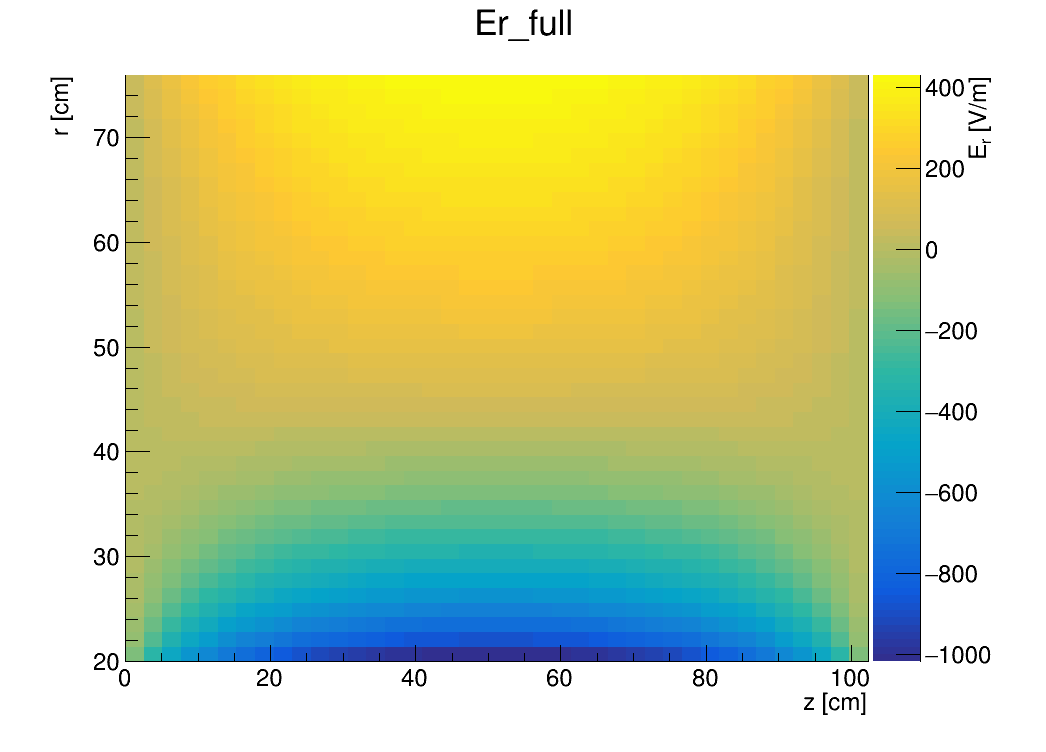

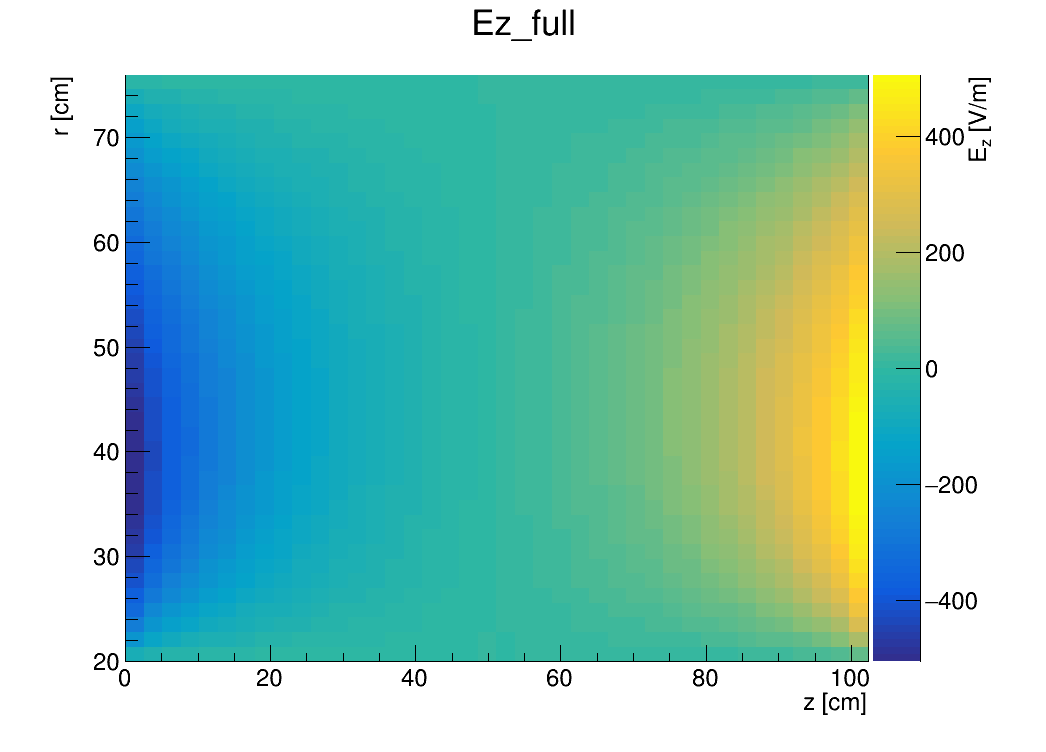

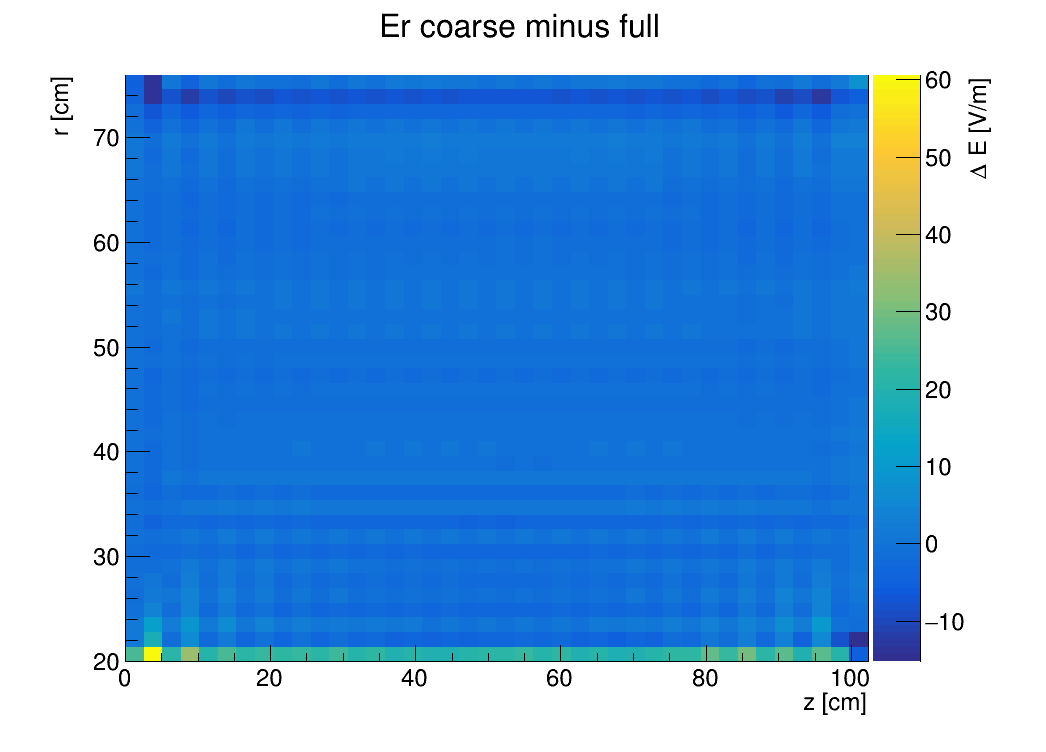

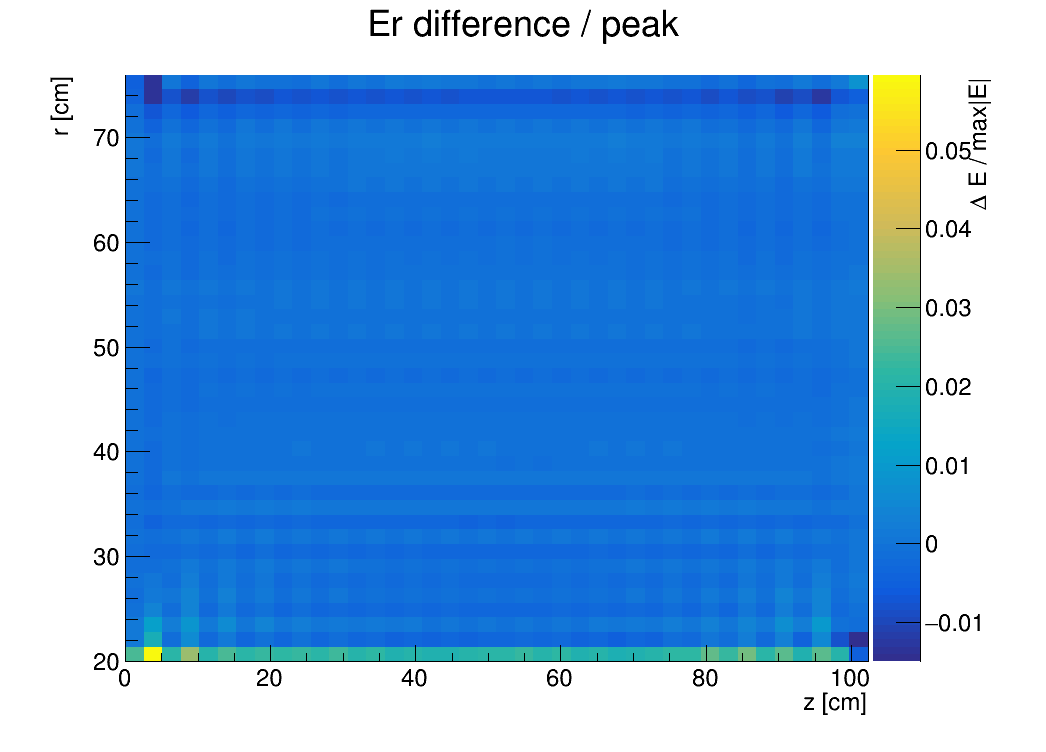

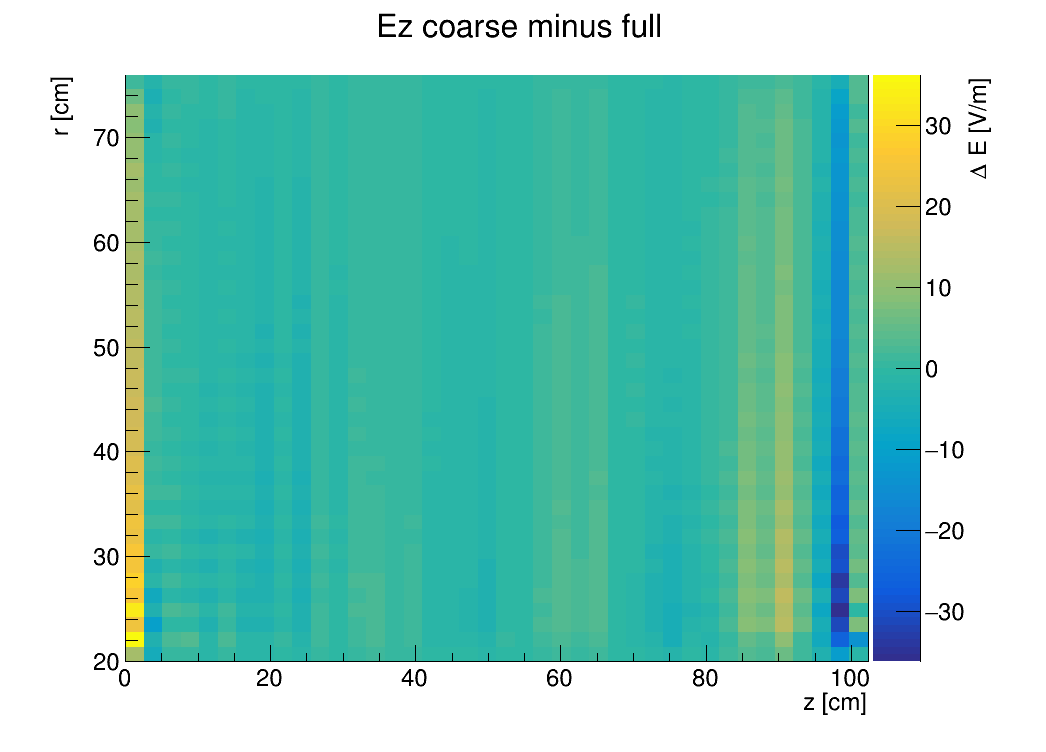

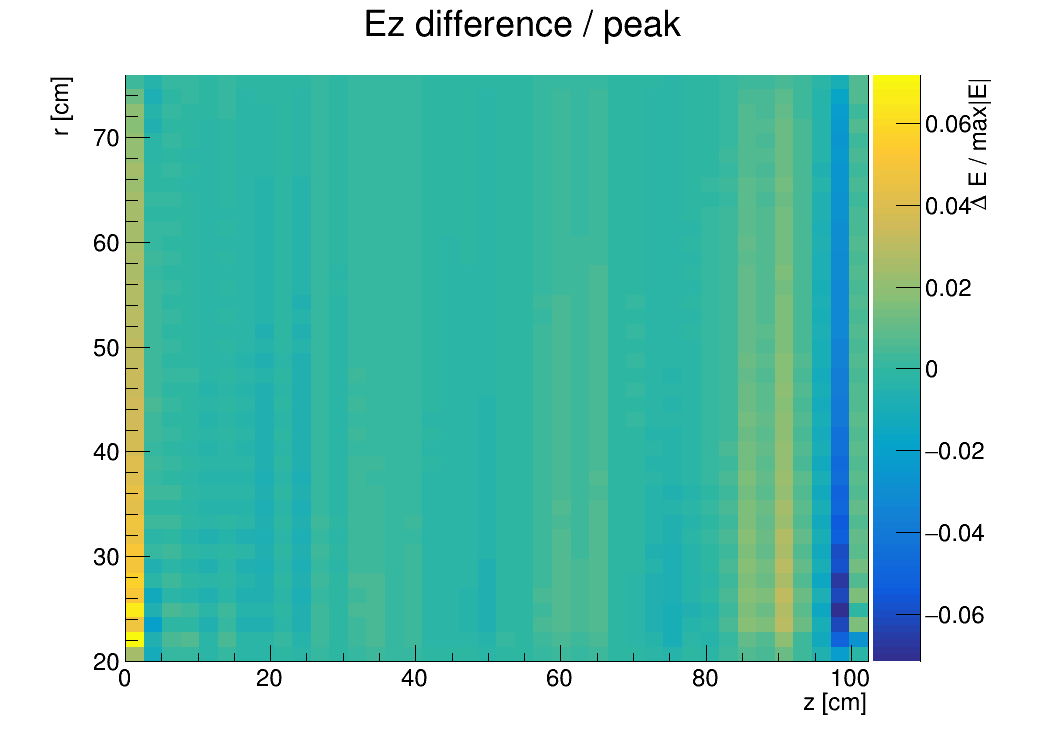

Info in <TCanvas::Print>: png file kernel_interpolation_qa/Er_full.png has been created
Info in <TCanvas::Print>: png file kernel_interpolation_qa/Ez_full.png has been created
Info in <TCanvas::Print>: png file kernel_interpolation_qa/Er_difference.png has been created
Info in <TCanvas::Print>: png file kernel_interpolation_qa/Er_fraction.png has been created
Info in <TCanvas::Print>: png file kernel_interpolation_qa/Ez_difference.png has been created
Info in <TCanvas::Print>: png file kernel_interpolation_qa/Ez_fraction.png has been created


In [24]:
qa_objects=[]; qa_canvases=[]
def make_th2(name,title,v,xe,ye,xt,yt,zt):
    h=root.TH2D(name,title,len(xe)-1,np.asarray(xe,dtype="d"),len(ye)-1,np.asarray(ye,dtype="d"))
    h.SetDirectory(0); h.GetXaxis().SetTitle(xt); h.GetYaxis().SetTitle(yt); h.GetZaxis().SetTitle(zt)
    for i in range(v.shape[0]):
        for j in range(v.shape[1]): h.SetBinContent(i+1,j+1,float(v[i,j]))
    qa_objects.append(h); return h

def draw(stem,h):
    c=root.TCanvas(stem,"",1050,780); c.SetRightMargin(.17); c.SetLeftMargin(.12); c.SetBottomMargin(.12)
    h.Draw("COLZ"); c.Update()
    fn=QA_DIR/f"{stem}.png"; c.SaveAs(str(fn)); display(Image(filename=str(fn)))
    qa_canvases.append(c)

Er_ref=np.mean(Er_full,axis=1); Ez_ref=np.mean(Ez_full,axis=1)
for name,field,ztitle in [("Er_full",Er_ref,"E_{r} [V/m]"),("Ez_full",Ez_ref,"E_{z} [V/m]")]:
    draw(name,make_th2("h"+name,name,field.T,z_obs_edges*M_TO_CM,r_obs_edges*M_TO_CM,"z [cm]","r [cm]",ztitle))

if DO_COARSE_KERNEL_TEST:
    for name,ref,test in [("Er",Er_ref,Er_coarse),("Ez",Ez_ref,Ez_coarse)]:
        diff=test-ref; peak=max(np.max(abs(ref)),1e-30)
        draw(name+"_difference",make_th2("h"+name+"Diff",name+" coarse minus full",diff.T,z_obs_edges*M_TO_CM,r_obs_edges*M_TO_CM,"z [cm]","r [cm]","#Delta E [V/m]"))
        draw(name+"_fraction",make_th2("h"+name+"Frac",name+" difference / peak",(diff/peak).T,z_obs_edges*M_TO_CM,r_obs_edges*M_TO_CM,"z [cm]","r [cm]","#Delta E / max|E|"))

## 14. Save regenerated field maps

The full-kernel fields are written to a three-dimensional ROOT file.

A separate PHGarfield-compatible file is written with the established histogram convention

```text
QA/hErDefault
QA/hEzDefault
```

using

$$
x=r,\qquad y=|z|,
$$

and field values in \(\mathrm{V/m}\).

In [13]:
def make_th3(name,title,v,xe,ye,ze):
    h=root.TH3D(name,title,len(xe)-1,np.asarray(xe,dtype="d"),len(ye)-1,np.asarray(ye,dtype="d"),len(ze)-1,np.asarray(ze,dtype="d"))
    for i in range(v.shape[0]):
        for j in range(v.shape[1]):
            for k in range(v.shape[2]): h.SetBinContent(i+1,j+1,k+1,float(v[i,j,k]))
    return h

f=root.TFile(OUTPUT_FIELD_FILE,"RECREATE")
for h in [
    make_th3("hRho","rho",rho,r_src_edges*M_TO_CM,phi_src_edges,z_src_edges*M_TO_CM),
    make_th3("hPhi","Phi",Phi_full,r_obs_edges*M_TO_CM,phi_obs_edges,z_obs_edges*M_TO_CM),
    make_th3("hEr","Er",Er_full,r_obs_edges*M_TO_CM,phi_obs_edges,z_obs_edges*M_TO_CM),
    make_th3("hEphi","Ephi",Ephi_full,r_obs_edges*M_TO_CM,phi_obs_edges,z_obs_edges*M_TO_CM),
    make_th3("hEz","Ez",Ez_full,r_obs_edges*M_TO_CM,phi_obs_edges,z_obs_edges*M_TO_CM)]: h.Write()
root.TNamed("metadata_json",json.dumps({
    "input_kernel_file":GREEN_KERNEL_FILE,
    "kernel_holdout":holdout_results,
    "axisymmetric_reduction":reduction_results,
    "coarse_kernel_fields":coarse_kernel_results,
    "field_interpolation":field_interpolation_results
},indent=2)).Write()
f.Close()

f=root.TFile(OUTPUT_GARFIELD_FILE,"RECREATE"); d=f.mkdir("QA"); d.cd()
make_th2("hErDefault","Er for PHGarfield",Er_ref,r_obs_edges*M_TO_CM,z_obs_edges*M_TO_CM,"r [cm]","|z| [cm]","E_{r} [V/m]").Write()
make_th2("hEzDefault","Ez for PHGarfield",Ez_ref,r_obs_edges*M_TO_CM,z_obs_edges*M_TO_CM,"r [cm]","|z| [cm]","E_{z} [V/m]").Write()
f.cd(); root.TNamed("metadata_json",json.dumps({"input_kernel_file":GREEN_KERNEL_FILE,"axis_order":["r_cm","local_abs_z_cm"],"field_units":"V/m"},indent=2)).Write(); f.Close()
print("Wrote",OUTPUT_FIELD_FILE)
print("Wrote",OUTPUT_GARFIELD_FILE)

Wrote sphenix_fields_from_stored_kernels.root
Wrote sphenix_garfield_fields_from_stored_kernels.root


## 14. Production direction for run-by-run fields

A practical run-by-run workflow is:

1. generate and validate geometry-dependent Green kernels once;
2. derive a run-dependent charge density from data;
3. convolve the stored kernels with that density;
4. pass the resulting field map to the distortion code.

For non-axisymmetric operation, storing the full dense six-dimensional kernel may be too expensive. A more compact production representation would usually store azimuthal Fourier components,

$$
K_m(r,z;r',z'),
$$

because only a limited number of \(m\) modes may be needed. This preserves run-dependent \(\phi\) structure while avoiding two dense azimuthal grid dimensions.